# Hyperparameter Search for $\lambda_{obs}$ vs $\alpha_{train}$

This notebook searches $\lambda_{obs}$ for each $\alpha_{train} \in \{1.0, 0.05\}$.

For each alpha: start from the same small $\lambda_{obs}$, train, evaluate the 95th quantile of maximum violation on the validation set, and update $\lambda_{obs}$:
- if quantile > 0: increase $\lambda_{obs}$
- else: decrease $\lambda_{obs}$

Goal: find a $\lambda_{obs}$ with violation quantile close to 0.

In [1]:
import os
import torch
import numpy as np
from dataclasses import dataclass, field

from performance_boosting import PBClosedLoop
from ren import ContractiveREN
from robot import RobotPlant, StabilizedRobot, PDController
from dataset import generate_random_batch
from losses_and_wrappers import PBLoss, SplitCVaRLossWrapper
from training_function import train_agent
from plot_functions import plot_pb_trajectories
from wakepy import keep

In [2]:
from __future__ import annotations

def set_seed(seed: int):
    torch.manual_seed(seed)
    np.random.seed(seed)


@dataclass
class ExperimentConfig:
    # --- 1. General Setup ---
    device: torch.device = field(default_factory=lambda: torch.device("cuda" if torch.cuda.is_available() else "cpu"))
    seed: int = 4

    # --- 2. Dataset Parameters ---
    noise_std: float = 0.0

    # --- 3. Physics & Dynamics Parameters ---
    n_agents: int = 1
    state_dim: int = 4
    input_dim: int = 2
    dt: float = 0.05

    b_nom: float = 1.0
    m_nom: float = 1.0
    b2_nom: float = 0.2

    b_sim: float = 1.0
    m_sim: float = 1.0
    b2_sim: float = 0.2

    # --- 4. REN and Base Controller Parameters ---
    initialization_std: float = 0.01
    dim_internal: int = 4
    dim_nl: int = 4
    kp: float = 1.0
    ki: float = 1.0

    # --- 5. Loss & Cost Parameters ---
    lambda_x: float = 4.0
    lambda_u: float = 0.0
    lambda_decoupling: float = 1.0
    lambda_obs: float = 1.0
    tau_safe_bar: float = 0.0
    track_mode: str = 'quadratic'
    coll_mode: str = 'rbf'

    # --- 6. Wrapper Parameters ---
    alpha_train: float = 0.2

    # --- 7. Training & Validation Parameters ---
    num_training_steps: int = 700
    n_inner_steps: int = 1
    log_interval: int = 5
    early_stopping_patience_limit: int = 200
    gradient_clipping: float | None = None
    batch_size: int = 200
    horizon: int = 500
    lr: float = 0.001
    num_val_samples: int = 500

    def __post_init__(self):
        self.x0_centers = [[-1.5, -1], [1.0, -1.0], [0.0, 1.0]]
        self.x0_stds = [0.3, 0.1, 0.1]
        self.x0_probs = [0.5, 0.45, 0.05]

        self.Q_agent = torch.diag(torch.tensor([1.0, 1.0, 1.0, 1.0])) * self.lambda_x
        self.Q = torch.kron(torch.eye(self.n_agents), self.Q_agent).to(self.device)

        self.R_agent = torch.eye(2) * self.lambda_u
        self.R = torch.kron(torch.eye(self.n_agents), self.R_agent).to(self.device)

        self.obs_centers = [torch.tensor([0.0, 0.6])]
        self.obs_radii = [[0.8, 0.1]]
        self.safety_factor = 1.0
        self.obs_radii_safe = [[r * self.safety_factor for r in obs] for obs in self.obs_radii]

        self.x_target = torch.zeros(4 * self.n_agents).to(self.device)


def build_training_objects(config: ExperimentConfig):
    sim_OL_plant = RobotPlant(b=config.b_sim, b2=config.b2_sim, m=config.m_sim, n_agents=config.n_agents).to(config.device)
    nominal_OL_plant = RobotPlant(b=config.b_nom, b2=config.b2_nom, m=config.m_nom, n_agents=config.n_agents).to(config.device)
    base_controller = PDController(kp=config.kp, ki=config.ki, n_agents=config.n_agents).to(config.device)

    f_sim = StabilizedRobot(sim_OL_plant, base_controller).to(config.device)
    f_nom = StabilizedRobot(nominal_OL_plant, base_controller).to(config.device)

    for param in f_sim.parameters():
        param.requires_grad = False
    for param in f_nom.parameters():
        param.requires_grad = False

    ren = ContractiveREN(
        dim_in=config.state_dim * config.n_agents,
        dim_out=config.input_dim * config.n_agents,
        dim_internal=config.dim_internal,
        dim_nl=config.dim_nl,
        initialization_std=config.initialization_std,
    ).to(config.device)

    sim = PBClosedLoop(ren, f_sim, f_nom).to(config.device)

    metric = PBLoss(
        x_target=config.x_target,
        Q=config.Q,
        R=config.R,
        lambda_obs=config.lambda_obs,
        obs_centers=config.obs_centers,
        obs_radii_safe=config.obs_radii_safe,
        n_agents=config.n_agents,
        track_mode=config.track_mode,
        coll_mode=config.coll_mode,
    ).to(config.device)

    wrapper = SplitCVaRLossWrapper(alpha=config.alpha_train, metric=metric, lambda_decoupling=config.lambda_decoupling).to(config.device)

    return sim, metric, wrapper


def compute_maximum_violation(traj_x: torch.Tensor, config: ExperimentConfig) -> torch.Tensor:
    x_reshaped = traj_x.view(traj_x.shape[0], traj_x.shape[1], config.n_agents, 4)
    pos = x_reshaped[..., :2]  # [B, H, N, 2]

    obs_centers_t = torch.stack(config.obs_centers).to(config.device)
    obs_radii_safe_t = torch.tensor(config.obs_radii_safe, dtype=torch.float32, device=config.device)

    centers = obs_centers_t.view(1, 1, 1, -1, 2)
    diff = pos.unsqueeze(3) - centers
    r_safe = obs_radii_safe_t.view(1, 1, 1, -1, 2)

    eps = 1e-12
    rho = torch.linalg.norm(diff / (r_safe + eps), dim=-1)
    rho_safe = torch.clamp(rho, min=eps)
    border_point = centers + diff / rho_safe.unsqueeze(-1)

    unsigned_dist = torch.linalg.norm(pos.unsqueeze(3) - border_point, dim=-1)
    signed_dist = torch.where(rho < 1.0, unsigned_dist, -unsigned_dist)

    min_safe_radius = r_safe.min(dim=-1).values.expand_as(signed_dist)
    signed_dist = torch.where(rho < 1e-9, min_safe_radius, signed_dist)

    maximum_violation = signed_dist.amax(dim=(1, 2, 3))
    return maximum_violation


def evaluate_model(sim, metric, fixed_val_w, config: ExperimentConfig):
    sim.eval()
    with torch.no_grad():
        traj_x_val, traj_u_val, _ = sim.run(fixed_val_w)
        _, cost_x_val, cost_u_val, _ = metric(traj_x_val, traj_u_val)

    perf_qr = cost_x_val + cost_u_val
    maximum_violation = compute_maximum_violation(traj_x_val, config)

    return {
        'mean_perf_qr': perf_qr.mean().item(),
        'violation_quantile_95': torch.quantile(maximum_violation, 0.95).item(),
        'violation_rate': (maximum_violation > 0.0).float().mean().item(),
    }

In [3]:
# Search settings
alpha_train_values = [1.0, 0.05]
initial_lambda_obs = 1.0
lambda_mult_up = 2.0
lambda_mult_down = 0.5
max_search_iters = 20

# Build one fixed validation batch shared across all runs
set_seed(4)
base_cfg = ExperimentConfig(alpha_train=alpha_train_values[0], lambda_obs=initial_lambda_obs)
fixed_val_w = generate_random_batch(base_cfg, custom_batch_size=base_cfg.num_val_samples)

search_results = {}
training_histories = {}
saved_model_paths = {}
checkpoint_dir = "lambda_search_checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

In [4]:
for alpha in alpha_train_values:
    print("=" * 90)
    print(f"Searching lambda_obs for alpha_train={alpha}")

    current_lambda = initial_lambda_obs
    best = None
    last_negative = None
    previous_direction = None
    stop_reason = "max_search_iters reached"
    training_histories[alpha] = []

    for it in range(1, max_search_iters + 1):
        set_seed(4 + it)
        cfg = ExperimentConfig(alpha_train=alpha, lambda_obs=current_lambda)

        sim, metric, wrapper = build_training_objects(cfg)

        with keep.presenting():
            history, _ = train_agent(
                config=cfg,
                sim=sim,
                loss_wrapper=wrapper,
                mode="standard_cvar",
                fixed_val_w=fixed_val_w,
                generate_random_batch=generate_random_batch,
                plot_results=False,
                plot_kwargs=None,
            )

        history_snapshot = {
            k: list(v) if isinstance(v, list) else v
            for k, v in history.items()
        }
        training_histories[alpha].append({
            'search_iter': it,
            'lambda_obs': current_lambda,
            'log_interval': cfg.log_interval,
            'history': history_snapshot,
        })

        metrics = evaluate_model(sim, metric, fixed_val_w, cfg)
        q95 = metrics['violation_quantile_95']
        abs_q95 = abs(q95)

        sim.ren.reset()
        ren_state_dict = {
            k: v.detach().cpu().clone()
            for k, v in sim.ren.state_dict().items()
            if k != 'x'
        }

        candidate = {
            'alpha_train': alpha,
            'lambda_obs': current_lambda,
            'mean_perf_qr': metrics['mean_perf_qr'],
            'violation_quantile_95': q95,
            'violation_rate': metrics['violation_rate'],
            'abs_q95': abs_q95,
            'search_iter': it,
            'ren_state_dict': ren_state_dict,
        }

        if (best is None) or (abs_q95 < best['abs_q95']):
            best = candidate

        if q95 < 0.0:
            last_negative = candidate

        print(
            f"iter={it:02d} | lambda_obs={current_lambda:.6f} | "
            f"q95={q95:.6f} | perf={metrics['mean_perf_qr']:.6f} | "
            f"viol_rate={metrics['violation_rate']:.2%}"
        )

        direction = "increase" if q95 > 0.0 else "decrease"

        if previous_direction is not None and direction != previous_direction:
            if last_negative is not None:
                best = last_negative
                stop_reason = (
                    f"direction flip detected ({previous_direction} -> {direction}); "
                    "retained last negative q95"
                )
            else:
                stop_reason = (
                    f"direction flip detected ({previous_direction} -> {direction}); "
                    "no negative q95 seen, kept best abs(q95)"
                )
            break

        previous_direction = direction

        if direction == "increase":
            current_lambda = min(current_lambda * lambda_mult_up, 1e6)
        else:
            current_lambda = max(current_lambda * lambda_mult_down, 1e-8)

    search_results[alpha] = best

    ckpt_path = os.path.join(
        checkpoint_dir,
        f"ren_alpha_{alpha:.2f}_lambda_{best['lambda_obs']:.6f}.pt"
    )
    torch.save(
        {
            'alpha_train': best['alpha_train'],
            'lambda_obs': best['lambda_obs'],
            'metrics': {
                'mean_perf_qr': best['mean_perf_qr'],
                'violation_quantile_95': best['violation_quantile_95'],
                'violation_rate': best['violation_rate'],
            },
            'ren_state_dict': best['ren_state_dict'],
        },
        ckpt_path,
    )
    saved_model_paths[alpha] = ckpt_path

    print(
        f"Selected lambda_obs={best['lambda_obs']:.6f} for alpha_train={alpha} "
        f"(best q95={best['violation_quantile_95']:.6f}; stop: {stop_reason})"
    )
    print(f"Saved retained model to: {ckpt_path}")

print("\nSearch completed for all alpha values.")

Searching lambda_obs for alpha_train=1.0
Starting STANDARD_CVAR online training on cpu...


Standard Cvar: 100%|██████████| 700/700 [04:11<00:00,  2.79it/s, Val Loss=0.4706, Best=0.4706]



Restored best model (Metric: 0.4706).
iter=01 | lambda_obs=1.000000 | q95=0.092923 | perf=0.470185 | viol_rate=5.40%
Starting STANDARD_CVAR online training on cpu...


Standard Cvar: 100%|██████████| 700/700 [04:15<00:00,  2.73it/s, Val Loss=0.4714, Best=0.4713]



Restored best model (Metric: 0.4713).
iter=02 | lambda_obs=2.000000 | q95=0.105646 | perf=0.470504 | viol_rate=5.40%
Starting STANDARD_CVAR online training on cpu...


...


Restored best model (Metric: 0.4993).
iter=08 | lambda_obs=128.000000 | q95=0.077064 | perf=0.476332 | viol_rate=5.40%
Starting STANDARD_CVAR online training on cpu...


Standard Cvar: 100%|██████████| 700/700 [04:22<00:00,  2.66it/s, Val Loss=0.5186, Best=0.5186]



Restored best model (Metric: 0.5186).
iter=09 | lambda_obs=256.000000 | q95=0.077476 | perf=0.480367 | viol_rate=5.40%
Starting STANDARD_CVAR online training on cpu...


Standard Cvar:  84%|████████▎ | 586/700 [03:40<00:42,  2.66it/s, Val Loss=0.5534, Best=0.5535]


KeyboardInterrupt: 

In [ ]:
print("Final comparison (using best lambda_obs per alpha_train):")
print("-" * 90)
print(f"{'alpha_train':>12} | {'lambda_obs':>12} | {'mean_perf_qr':>14} | {'viol_q95':>12} | {'viol_rate':>10}")
print("-" * 90)

for alpha in alpha_train_values:
    r = search_results[alpha]
    print(
        f"{r['alpha_train']:>12.3f} | {r['lambda_obs']:>12.6f} | {r['mean_perf_qr']:>14.6f} | "
        f"{r['violation_quantile_95']:>12.6f} | {r['violation_rate']:>9.2%}"
    )

print("-" * 90)

Final comparison (using best lambda_obs per alpha_train):
------------------------------------------------------------------------------------------
 alpha_train |   lambda_obs |   mean_perf_qr |     viol_q95 |  viol_rate
------------------------------------------------------------------------------------------
       1.000 |     8.000000 |       0.611186 |    -0.028519 |     1.60%
       0.050 |     1.000000 |       0.604679 |    -0.053300 |     0.20%
------------------------------------------------------------------------------------------


## Training curves for all search runs

These plots show the training dynamics for every run performed during the lambda search (all iterations for each `alpha_train`).

Training curves for alpha_train=1.0 (4 runs)


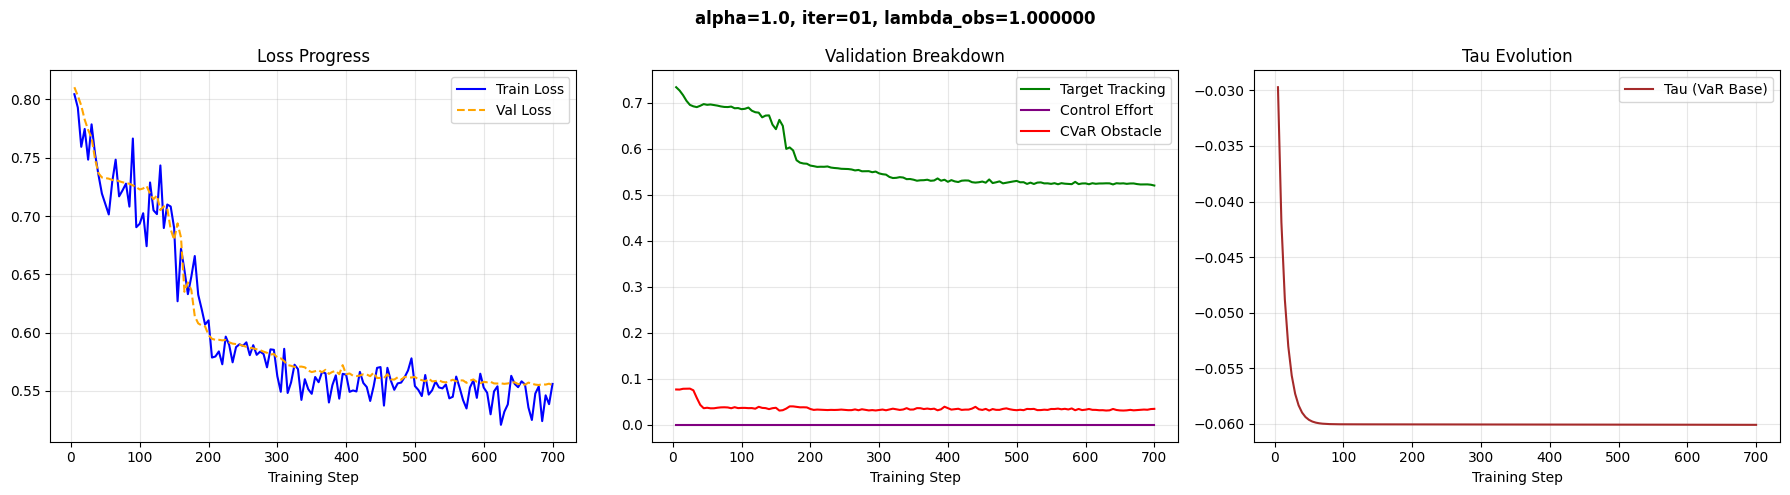

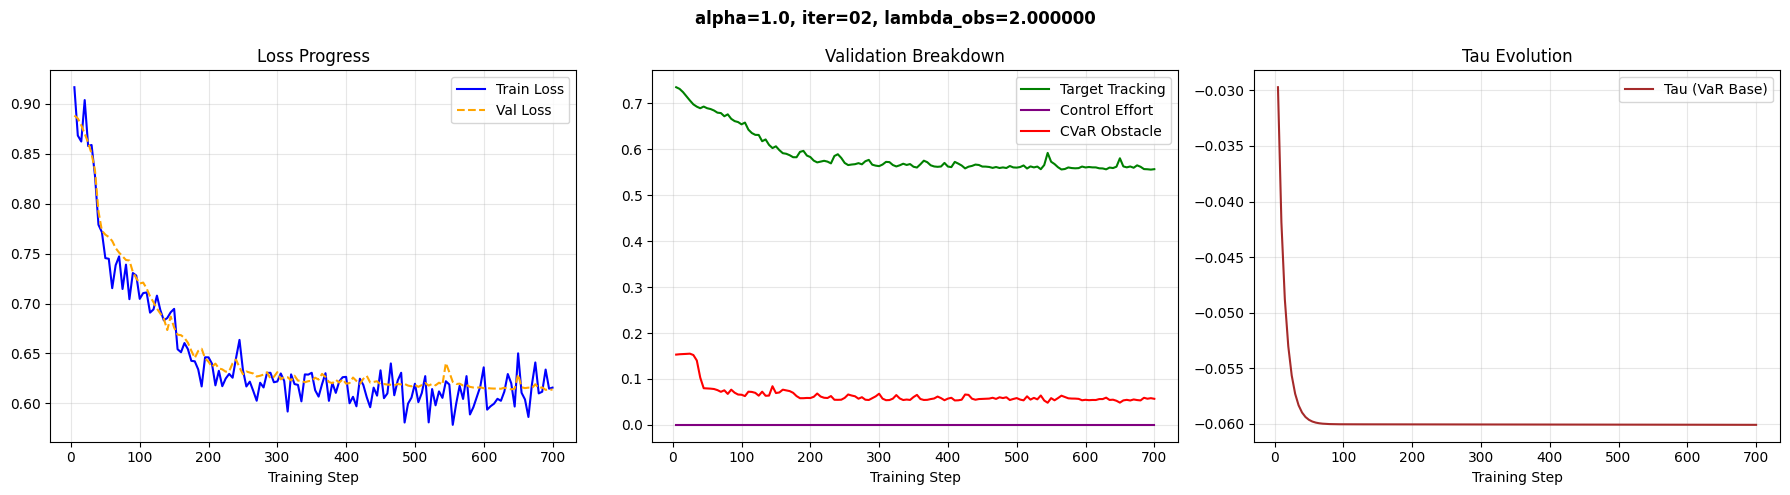

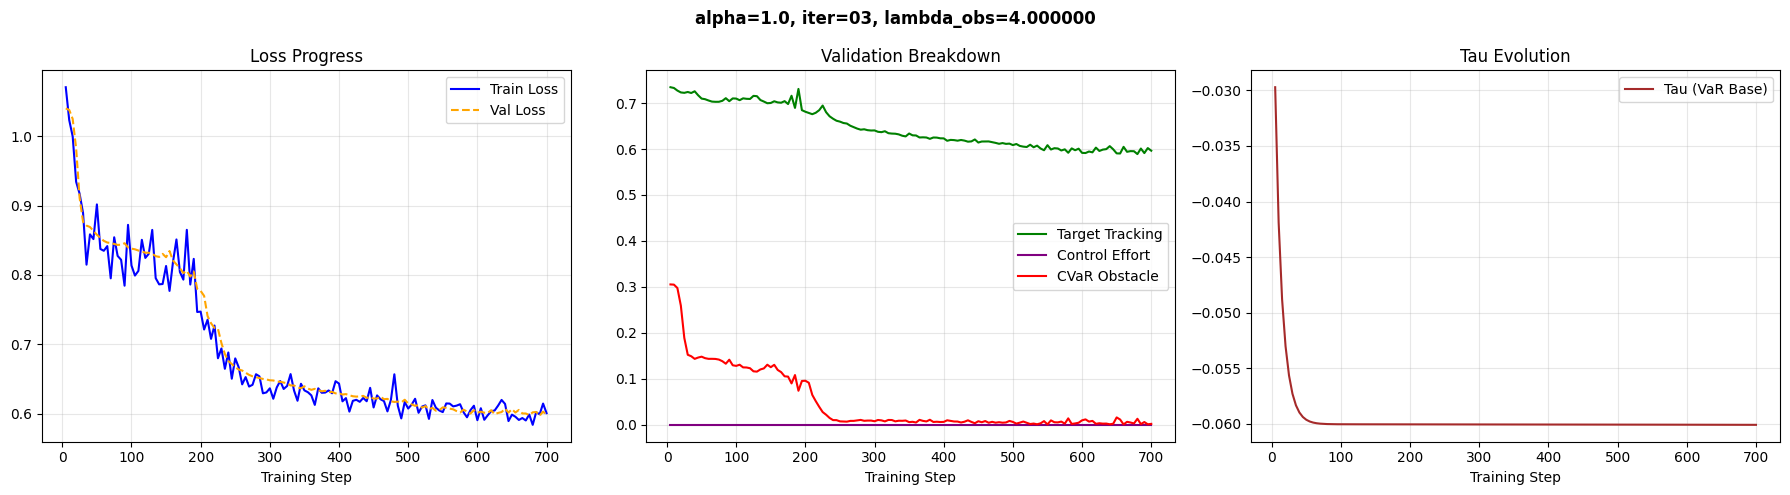

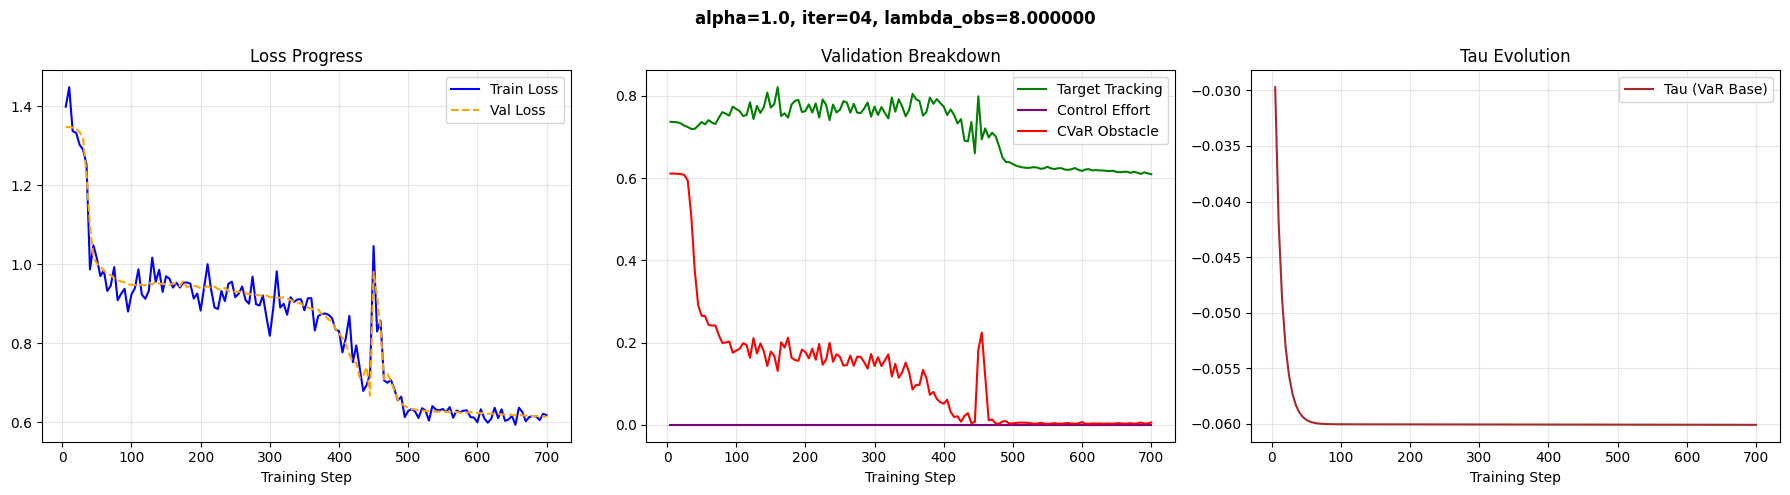

Training curves for alpha_train=0.05 (2 runs)


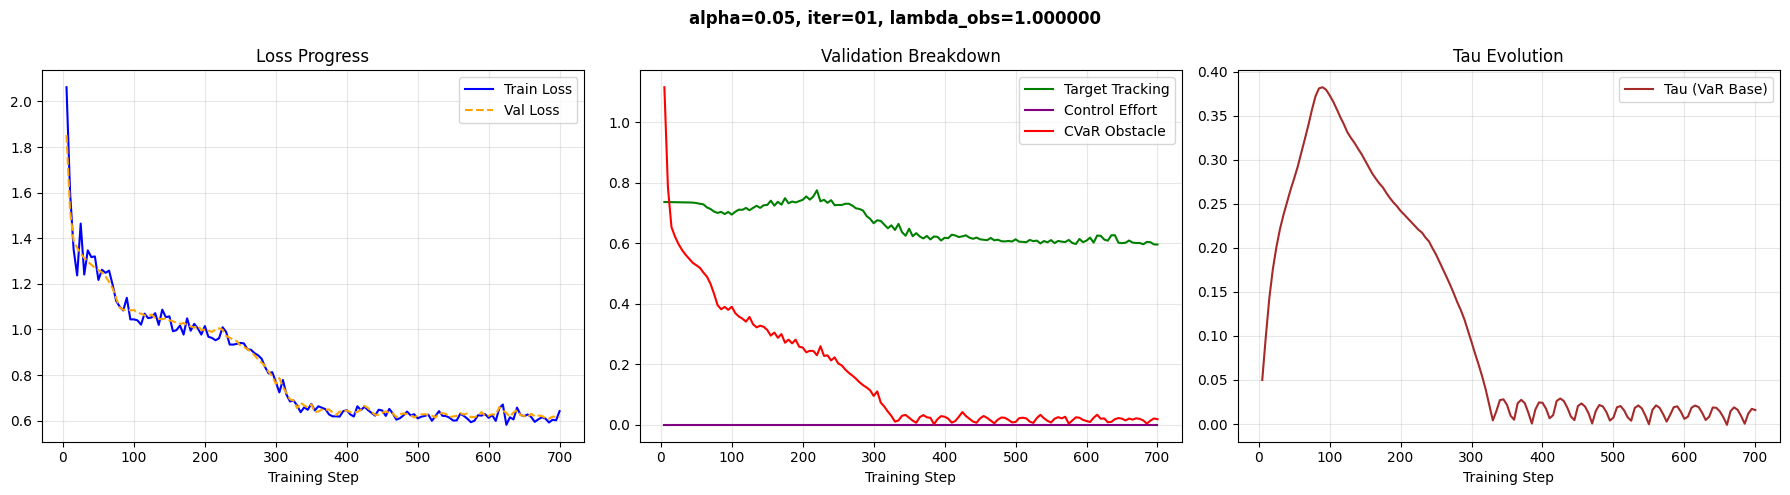

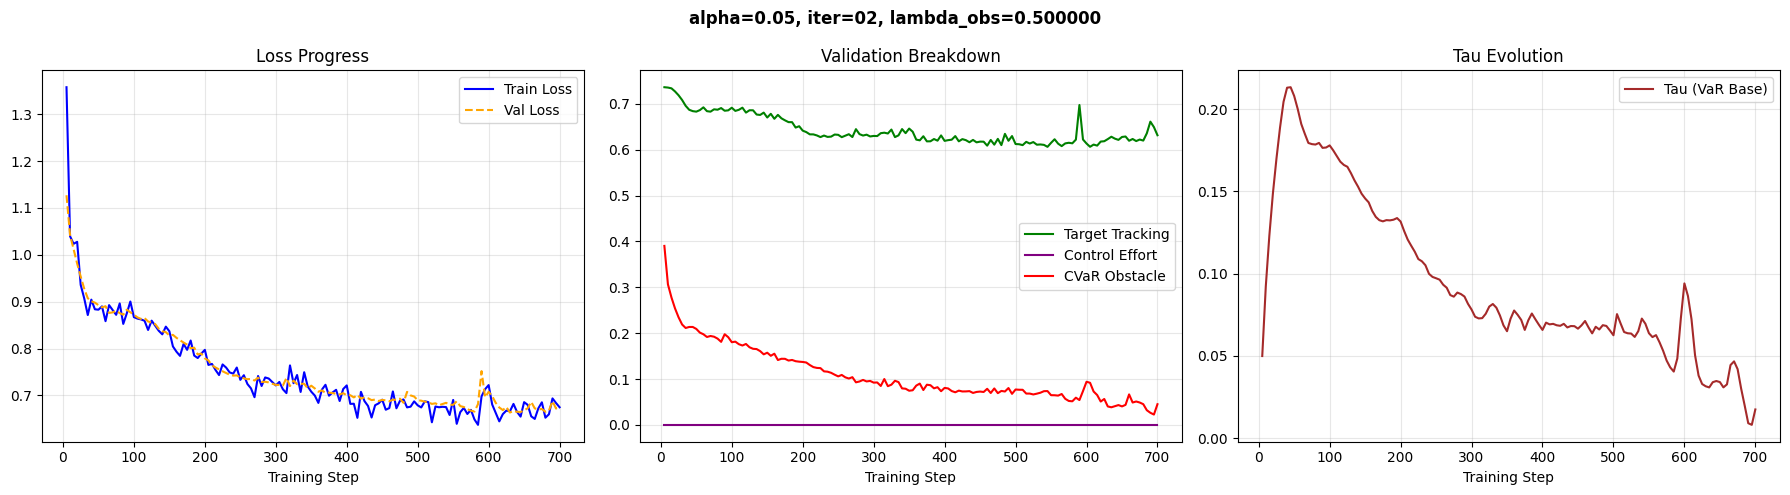

In [ ]:
import matplotlib.pyplot as plt

for alpha in alpha_train_values:
    runs = training_histories.get(alpha, [])
    print("=" * 90)
    print(f"Training curves for alpha_train={alpha} ({len(runs)} runs)")

    for run in runs:
        hist = run['history']
        n_points = len(hist.get('val_losses', []))
        if n_points == 0:
            print(
                f"Skipping run iter={run['search_iter']:02d}, "
                f"lambda_obs={run['lambda_obs']:.6f} (no logged points)."
            )
            continue

        steps = range(
            run['log_interval'],
            run['log_interval'] * n_points + 1,
            run['log_interval'],
        )

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle(
            f"alpha={alpha}, iter={run['search_iter']:02d}, "
            f"lambda_obs={run['lambda_obs']:.6f}",
            fontsize=12,
            fontweight='bold'
        )

        axes[0].plot(steps, hist.get('train_losses', []), label='Train Loss', color='blue')
        axes[0].plot(steps, hist.get('val_losses', []), label='Val Loss', color='orange', linestyle='--')
        axes[0].set_title('Loss Progress')
        axes[0].set_xlabel('Training Step')
        axes[0].grid(True, alpha=0.3)
        axes[0].legend()

        axes[1].plot(steps, hist.get('val_targets', []), label='Target Tracking', color='green')
        axes[1].plot(steps, hist.get('val_us', []), label='Control Effort', color='purple')
        axes[1].plot(steps, hist.get('val_obss', []), label='CVaR Obstacle', color='red')
        axes[1].set_title('Validation Breakdown')
        axes[1].set_xlabel('Training Step')
        axes[1].grid(True, alpha=0.3)
        axes[1].legend()

        axes[2].plot(steps, hist.get('taus', []), label='Tau (VaR Base)', color='brown')
        axes[2].set_title('Tau Evolution')
        axes[2].set_xlabel('Training Step')
        axes[2].grid(True, alpha=0.3)
        axes[2].legend()

        plt.tight_layout()
        plt.show()

## Trajectory diagnostics of best models

For each retained model (one per `alpha_train`), reload checkpoint, simulate trajectories on a fresh batch, and plot:
- 2D object motion with obstacles/target
- X/Y position evolution
- control effort
- disturbance estimates

Retained model for alpha_train=1.0: lambda_obs=8.000000
Loading checkpoint: lambda_search_checkpoints/ren_alpha_1.00_lambda_8.000000.pt
Skipped non-compatible checkpoint keys: ['x']
Missing keys after load (using init defaults): ['x']
Diagnostics on plotting batch | perf=0.612039, q95=-0.009098, viol_rate=3.00%


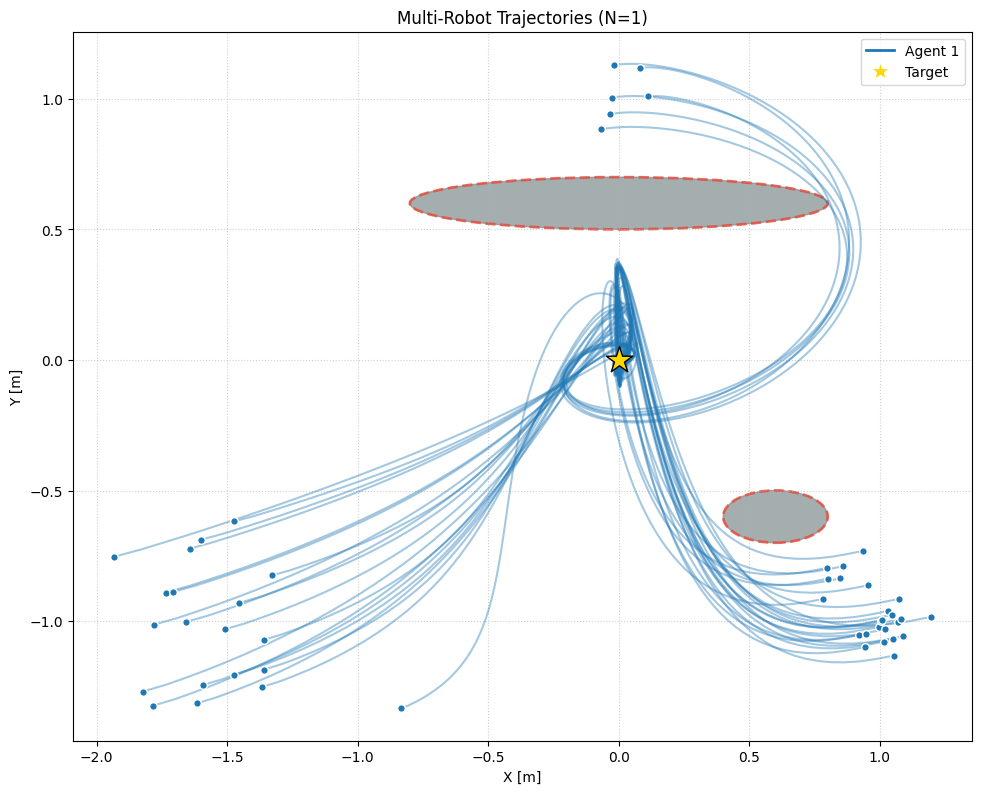

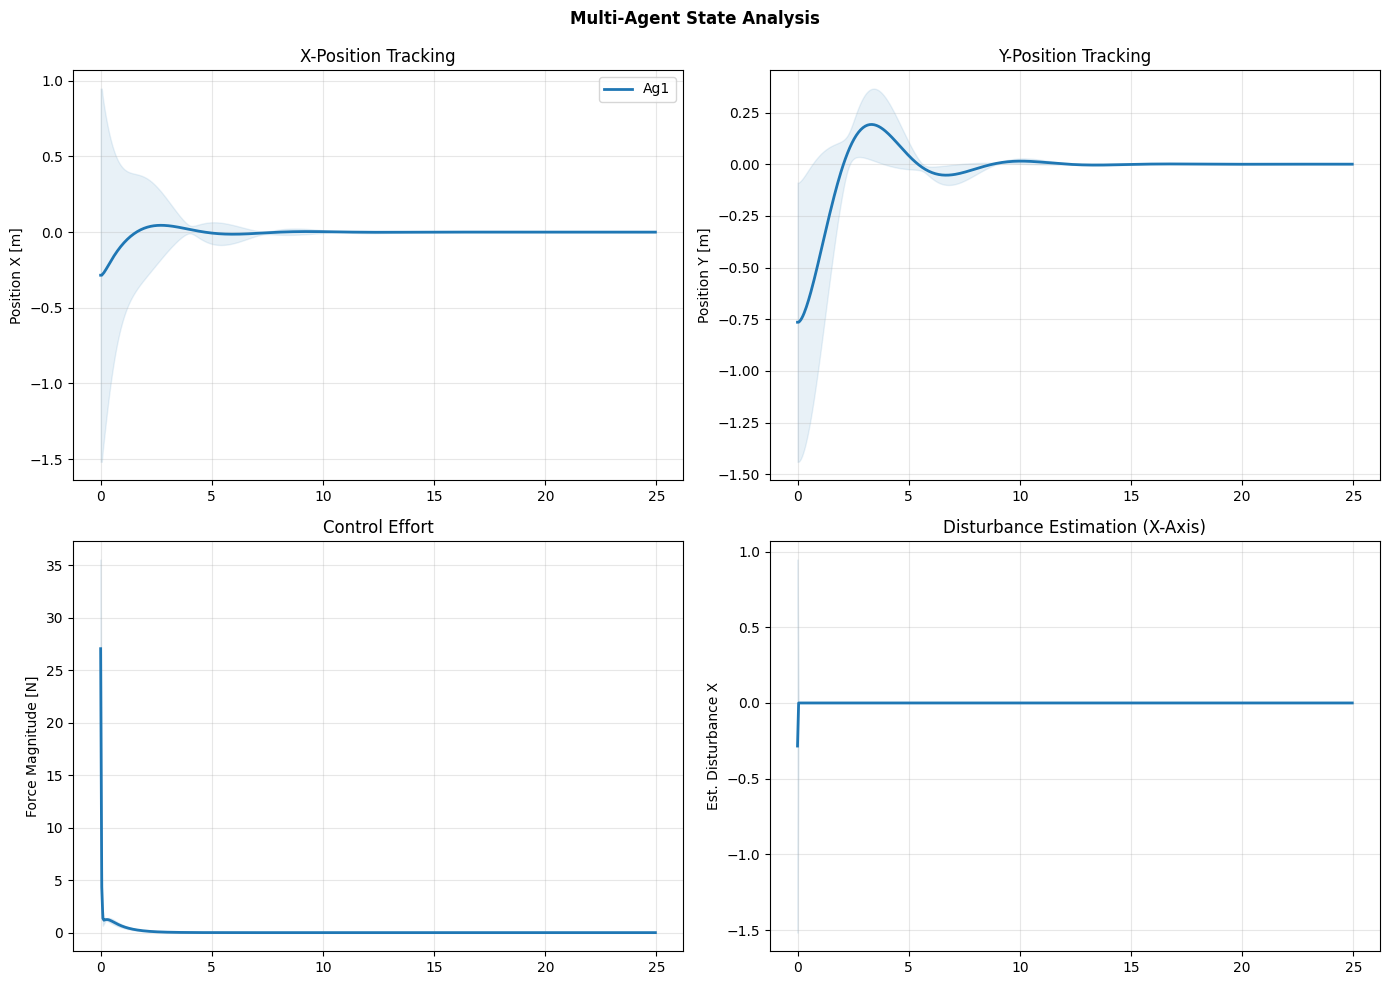

Retained model for alpha_train=0.05: lambda_obs=1.000000
Loading checkpoint: lambda_search_checkpoints/ren_alpha_0.05_lambda_1.000000.pt
Skipped non-compatible checkpoint keys: ['x']
Missing keys after load (using init defaults): ['x']
Diagnostics on plotting batch | perf=0.603030, q95=-0.050176, viol_rate=1.50%


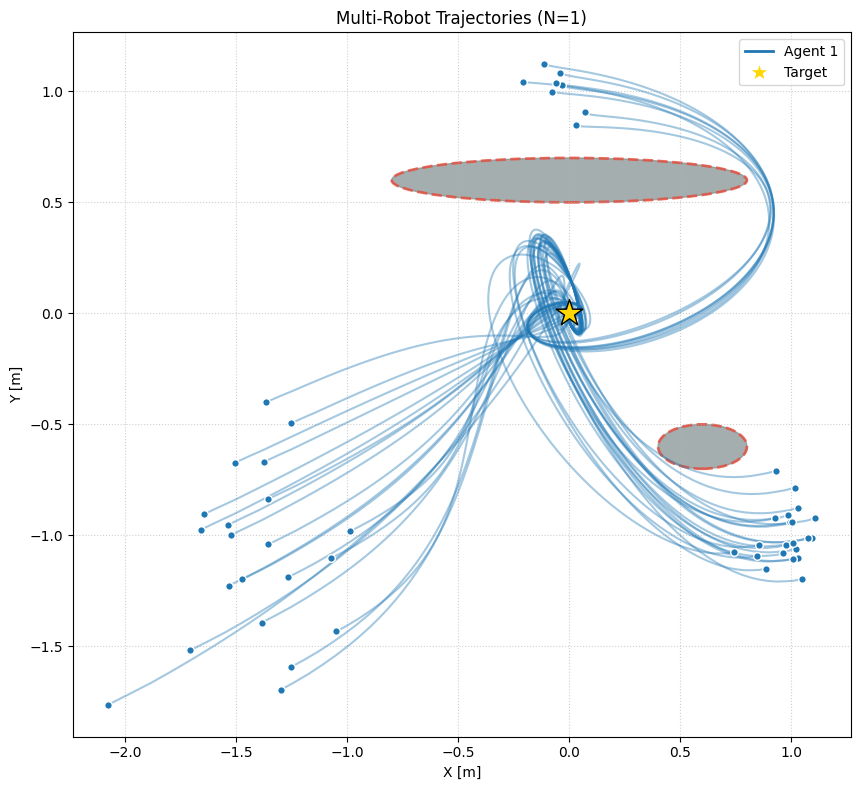

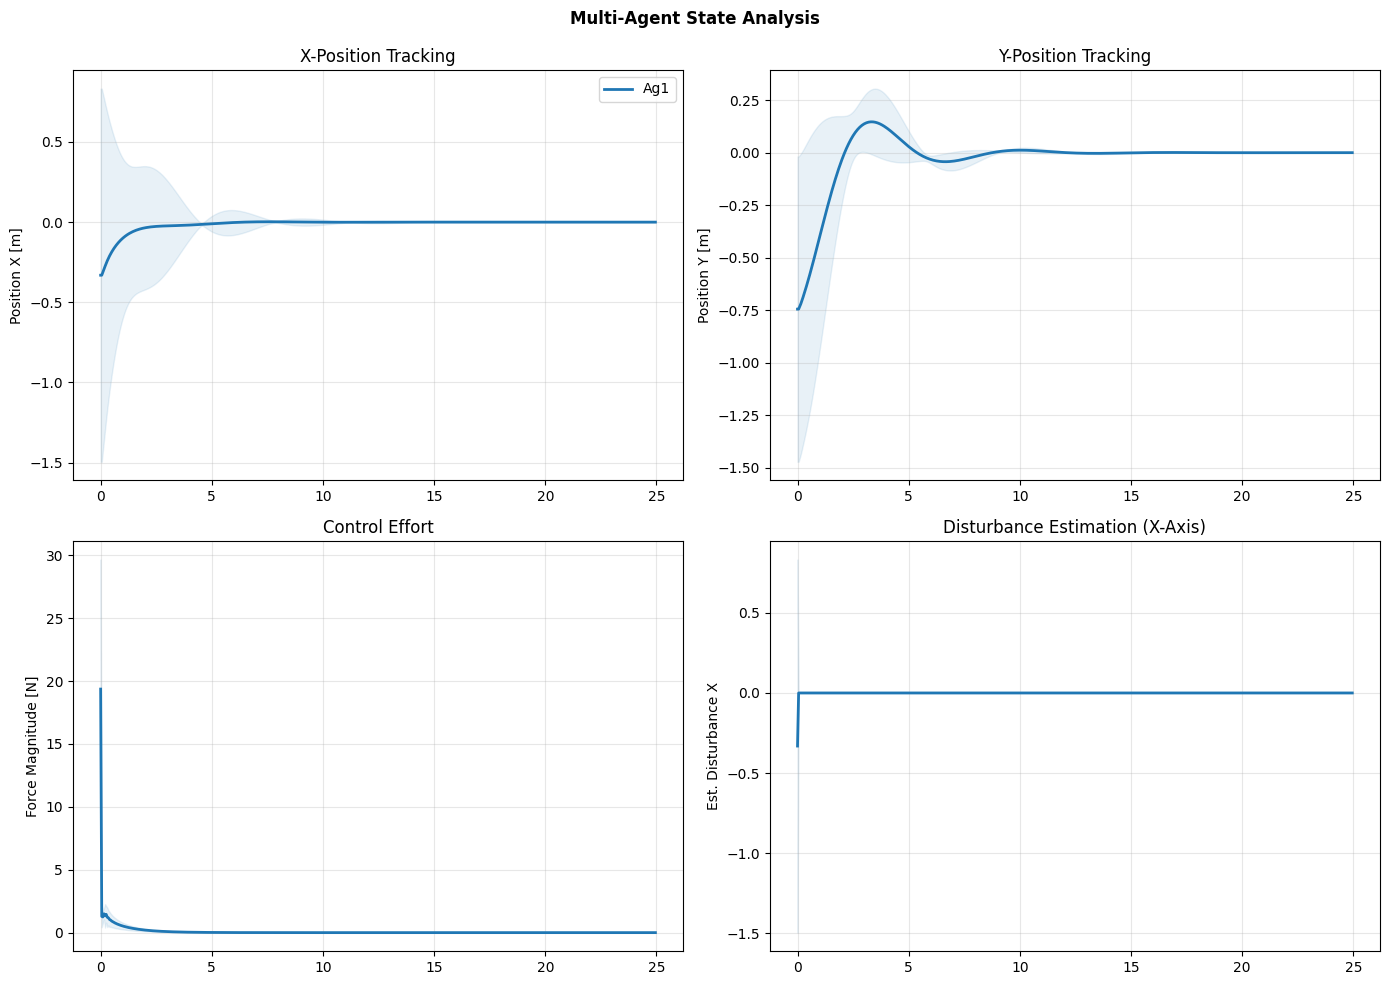

In [ ]:
# Plot settings
plot_batch_size = 200

for alpha in alpha_train_values:
    print("=" * 90)
    retained = search_results[alpha]
    ckpt_path = saved_model_paths[alpha]

    print(
        f"Retained model for alpha_train={alpha}: "
        f"lambda_obs={retained['lambda_obs']:.6f}"
    )
    print(f"Loading checkpoint: {ckpt_path}")

    cfg_best = ExperimentConfig(alpha_train=alpha, lambda_obs=retained['lambda_obs'])
    sim_best, metric_best, _ = build_training_objects(cfg_best)

    checkpoint = torch.load(ckpt_path, map_location=cfg_best.device)
    saved_state = checkpoint['ren_state_dict']
    current_state = sim_best.ren.state_dict()

    compatible_state = {
        k: v
        for k, v in saved_state.items()
        if (k in current_state) and (current_state[k].shape == v.shape)
    }
    skipped_keys = [
        k for k in saved_state.keys()
        if (k not in compatible_state)
    ]

    load_result = sim_best.ren.load_state_dict(compatible_state, strict=False)
    if skipped_keys:
        print(f"Skipped non-compatible checkpoint keys: {skipped_keys}")
    if load_result.missing_keys:
        print(f"Missing keys after load (using init defaults): {load_result.missing_keys}")

    sim_best.eval()

    set_seed(123 + int(alpha * 100))
    plot_w = generate_random_batch(cfg_best, custom_batch_size=plot_batch_size)

    with torch.no_grad():
        traj_x_best, traj_u_best, traj_w_hat_best = sim_best.run(plot_w)
        metrics_best = evaluate_model(sim_best, metric_best, plot_w, cfg_best)

    print(
        f"Diagnostics on plotting batch | "
        f"perf={metrics_best['mean_perf_qr']:.6f}, "
        f"q95={metrics_best['violation_quantile_95']:.6f}, "
        f"viol_rate={metrics_best['violation_rate']:.2%}"
    )

    plot_pb_trajectories(
        traj_x=traj_x_best,
        traj_u=traj_u_best,
        traj_w_hat=traj_w_hat_best,
        x_target=cfg_best.x_target,
        obs_centers=cfg_best.obs_centers,
        obs_radii=cfg_best.obs_radii,
        obs_radii_safe=cfg_best.obs_radii_safe,
        dt=cfg_best.dt,
    )